In [8]:
import sys
sys.path.append(r'C:\Users\Maahir\AppData\Roaming\Python\Python311\site-packages')
import matplotlib.pyplot as plt


In [10]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [67]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'origin', 'car name']

dataset = pd.read_csv("Fuel Efficiency Predictor.csv")

dataset = dataset.drop("car name", axis=1)

dataset['horsepower'] = pd.to_numeric(dataset['horsepower'], errors='coerce')
dataset = dataset.dropna()        #to drop null values (i.e. with ? from dataset)

In [68]:
print(dataset.columns)
print(dataset.head())


Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin'],
      dtype='object')
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


In [69]:
origin = dataset.pop("origin") #origin is a pandas series (like a column of a dataframe) NOT a python list
dataset["USA"] = (origin==1) * 1.0  #makes a new column USA which will have 0 for car not of USA and 1 for car of USA. origin==1 compares each row whether it has value of origin as 1 and returns 1 or 0 (boolean)
dataset["Europe"] = (origin==2) * 1.0 #same as USA, this makes column Europe. keeps values 1 for cars in europe(i.e. with origin value as 2) and 0 for others
dataset["Japan"] = (origin==3) * 1.0 # same as both the above, this makes new column Japan with same concept

# This process is called One Hot Encoding

In [70]:
print(dataset['USA'].head())



0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: USA, dtype: float64


In [71]:
print(origin.head(10))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: origin, dtype: int64


In [72]:
train_dataset = dataset.sample(frac=0.8,random_state=0)
test_dataset = dataset.drop(train_dataset.index)

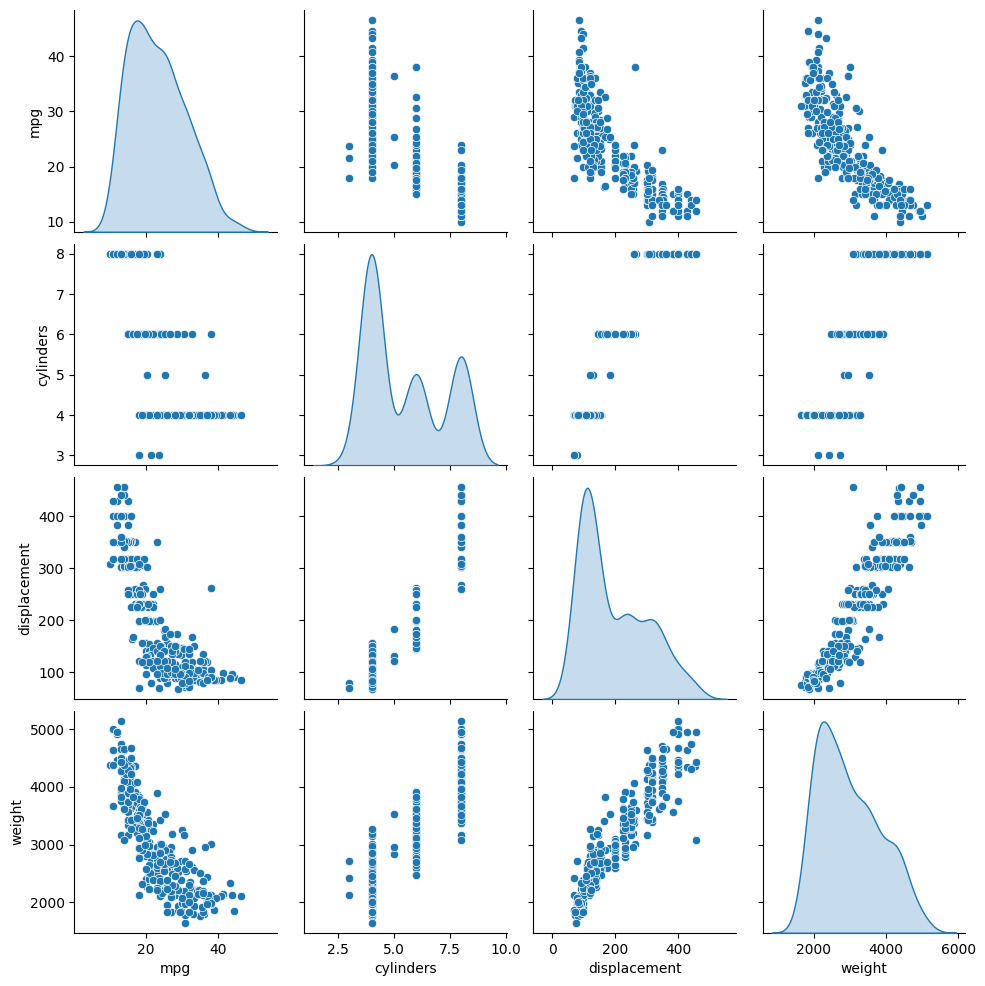

In [73]:
sns.pairplot(train_dataset[["mpg", "cylinders", "displacement", "weight"]], diag_kind="kde")

In [74]:
train_labels = train_dataset.pop('mpg')
test_labels = test_dataset.pop('mpg')

In [75]:
train_stats = train_dataset.describe()
train_stats = train_stats.transpose()

def norm(x):
    return (x - train_stats['mean']) / train_stats['std']

normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)


In [76]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation=tf.nn.relu, input_shape=[len(train_dataset.keys())]),
        layers.Dense(64, activation=tf.nn.relu),
        layers.Dense(1)
    ])

    optimizer = tf.keras.optimizers.RMSprop(0.001)

    model.compile(loss='mean_squared_error',
                 optimizer = optimizer,
                 metrics=['mean_absolute_error', 'mean_squared_error'])
    return model
model = build_model()
model.summary()

C:\Users\Maahir\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model.fit(normed_train_data, train_labels, epochs=100, verbose=1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 546.1616 - mean_absolute_error: 22.1326 - mean_squared_error: 546.1616
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 467.8197 - mean_absolute_error: 20.4647 - mean_squared_error: 467.8197 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 375.8127 - mean_absolute_error: 18.1996 - mean_squared_error: 375.8127 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 324.1887 - mean_absolute_error: 16.7165 - mean_squared_error: 324.1887 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 216.0648 - mean_absolute_error: 13.2929 - mean_squared_error: 216.0648 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 146.7681 - mean_absolute_error: 10.6472 - mean_squared_error: 146.7681 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 85.2791 - mean_absolute_error: 7.9095 - mean_squared_error: 85.2791   
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 54.5726 - mean_absolute_e

In [81]:
loss, mae, mse= model.evaluate(normed_test_data, test_labels, verbose=1)
print(f"Test MPG: {mae:.2f} MPG")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.7645 - mean_absolute_error: 1.6801 - mean_squared_error: 4.7645
Test MPG: 1.77 MPG


In [82]:
test_predictions = model.predict(normed_test_data).flatten()  #.flatten converts 2D array into 1D array
test_predictions

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([14.908673 , 11.961001 , 12.235806 , 23.528011 , 21.014841 ,
       13.053013 , 13.2858   , 12.897656 , 19.809286 , 29.880762 ,
       24.884813 , 23.382082 , 14.257478 , 26.466644 , 12.84754  ,
       14.003535 , 14.261509 , 13.14795  , 18.964693 , 12.764795 ,
       13.652467 , 26.44766  , 20.389345 , 22.031658 , 29.899961 ,
       24.102892 , 16.332584 , 22.6326   , 17.47538  , 18.592562 ,
       27.430725 , 21.307028 , 18.995472 , 21.799055 , 26.48032  ,
       15.3376875, 19.506668 , 28.605139 , 30.608343 , 17.369444 ,
       30.507128 , 28.578627 , 15.479787 , 35.977806 , 35.12697  ,
       35.416172 , 20.083239 , 22.085619 , 19.768515 , 25.276257 ,
       31.238752 , 20.389393 , 31.75438  , 18.835058 , 18.17444  ,
       18.288134 , 34.658966 , 34.252876 , 21.647783 , 25.09513  ,
       39.016277 , 32.533226 , 27.768332 , 28.060198 , 32.556297 ,
       38.9642   , 36.22887  , 35.43658  , 35.422375 , 30.877926 ,
       22.319141 , 24.25774  , 28.74055  , 30.095049 , 38.0575

In [86]:
for i in range(5):
    print(f"True MPG: {test_labels.values[i]:.2f}, Predicted: {test_predictions[i]:.2f}")  #for comparison
     


True MPG: 15.00, Predicted: 14.91
True MPG: 10.00, Predicted: 11.96
True MPG: 9.00, Predicted: 12.24
True MPG: 25.00, Predicted: 23.53
True MPG: 19.00, Predicted: 21.01


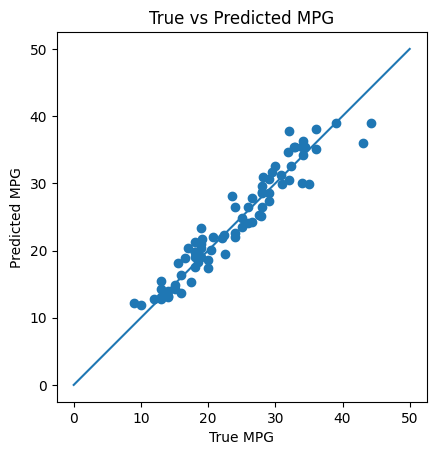

In [87]:
plt.scatter(test_labels,test_predictions)
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("True vs Predicted MPG")
plt.plot([0, 50], [0, 50]) #draws ideal case line when x=y
plt.axis("equal") #equal scale on X and Y axis
plt.axis("square") #the plot is a square, not rectangle
plt.show()